In [8]:
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import torch as pt
import os
import PcmPy as pcm
import HierarchBayesParcel.full_model as fm
import HierarchBayesParcel.util as ut
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.evaluation as ev
from OptimalBattery.util import eigenval_crit,build_combinations, combination_vectors
from DCBC.utilities import compute_dist
import nitools as nt
from IndividualParcellation.evaluate import calc_test_dcbc


In [9]:
# pytorch cuda global flag: True - cuda; False - cpu
if pt.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
pt.set_default_device(DEVICE)
pt.set_default_dtype(pt.float32)

print('DEVICE:', DEVICE)

DEVICE: cuda


In [10]:
# load data and info from pickle
with open('E:/data/data_mdtb_s1_SUIT3.pkl', 'rb') as f:
    data_mdtb_s1 = pickle.load(f)



#load info
with open('E:/data/info_mdtb_1.pkl', 'rb') as f:
    info = pickle.load(f)

In [11]:

# n_subjects, n_conditions_x_runs, n_voxels = data_mdtb_s1.shape


# new_data = np.zeros((n_subjects, n_conditions_x_runs, n_voxels))

# new_info_list = []

# condition_names = info['cond_name'].unique()

# for condition_idx, cond_name in enumerate(condition_names):
#     # Get the indices for all 16 repetitions of the current condition
#     indices = info[info['cond_name'] == cond_name].index

#     # Split into 4 groups, each having 4 repetitions
#     for run_reconstruct in range(4):
#         # Extract the relevant indices for this group of 4 repetitions
#         selected_indices = indices[run_reconstruct * 4 : (run_reconstruct + 1) * 4]

#         # Place these rows in the new data matrix in the appropriate position
#         # We place them sequentially to form the new data structure
#         new_data[:, (condition_idx * 16) + (run_reconstruct * 4): (condition_idx * 16) + (run_reconstruct * 4) + 4, :] = \
#             data_mdtb_s1[:, selected_indices, :]

#         # Generate new condition names and update the info entries
#         for sub_idx in range(4):
#             # Create new condition name like ToM1, ToM2, ...
#             new_condition_name = f"{cond_name}{sub_idx + 1}"
            
#             # Create a new info entry
#             new_info_list.append({
#                 'cond_name': new_condition_name,
#                 'run': run_reconstruct + 1,  # Assign to the virtual run index
#                 'task_name': info.loc[indices[0], 'task_name'],  # Keep the original task name
#                 'cond_num': condition_idx + 1,  # Use the condition index as a unique identifier
#                 'instruction': info.loc[indices[0], 'instruction'],
#                 'cond_code': f"{new_condition_name}-run{run_reconstruct + 1}"
#             })

# # Step 5: Convert the list of new info entries into a DataFrame
# info_new = pd.DataFrame(new_info_list)



# get the G matrix

In [13]:
n_conds = len(np.unique(info['cond_name']))
n_runs = len(np.unique(info['run']))
cond_names = np.unique(info['cond_name'])

cond_vec = np.tile(np.arange(1, n_conds + 1), n_runs)
part_vec = np.repeat(np.arange(1, n_runs + 1), n_conds)


In [14]:
# n_conds = len(np.unique(info_new['cond_name']))
# n_runs = len(np.unique(info_new['run']))
# cond_names = info_new['cond_name'].unique()

# cond_vec = np.concatenate([np.tile(np.arange(start, start + 4), 4) for start in range(1, 117, 4)])
# part_vec = np.tile(np.repeat([1, 2, 3, 4], 4), 29)

In [15]:
Gs_list = []
for i in range(data_mdtb_s1.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1[i], cond_vec, part_vec)
    Gs_list.append(Gs)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)


<Axes: >

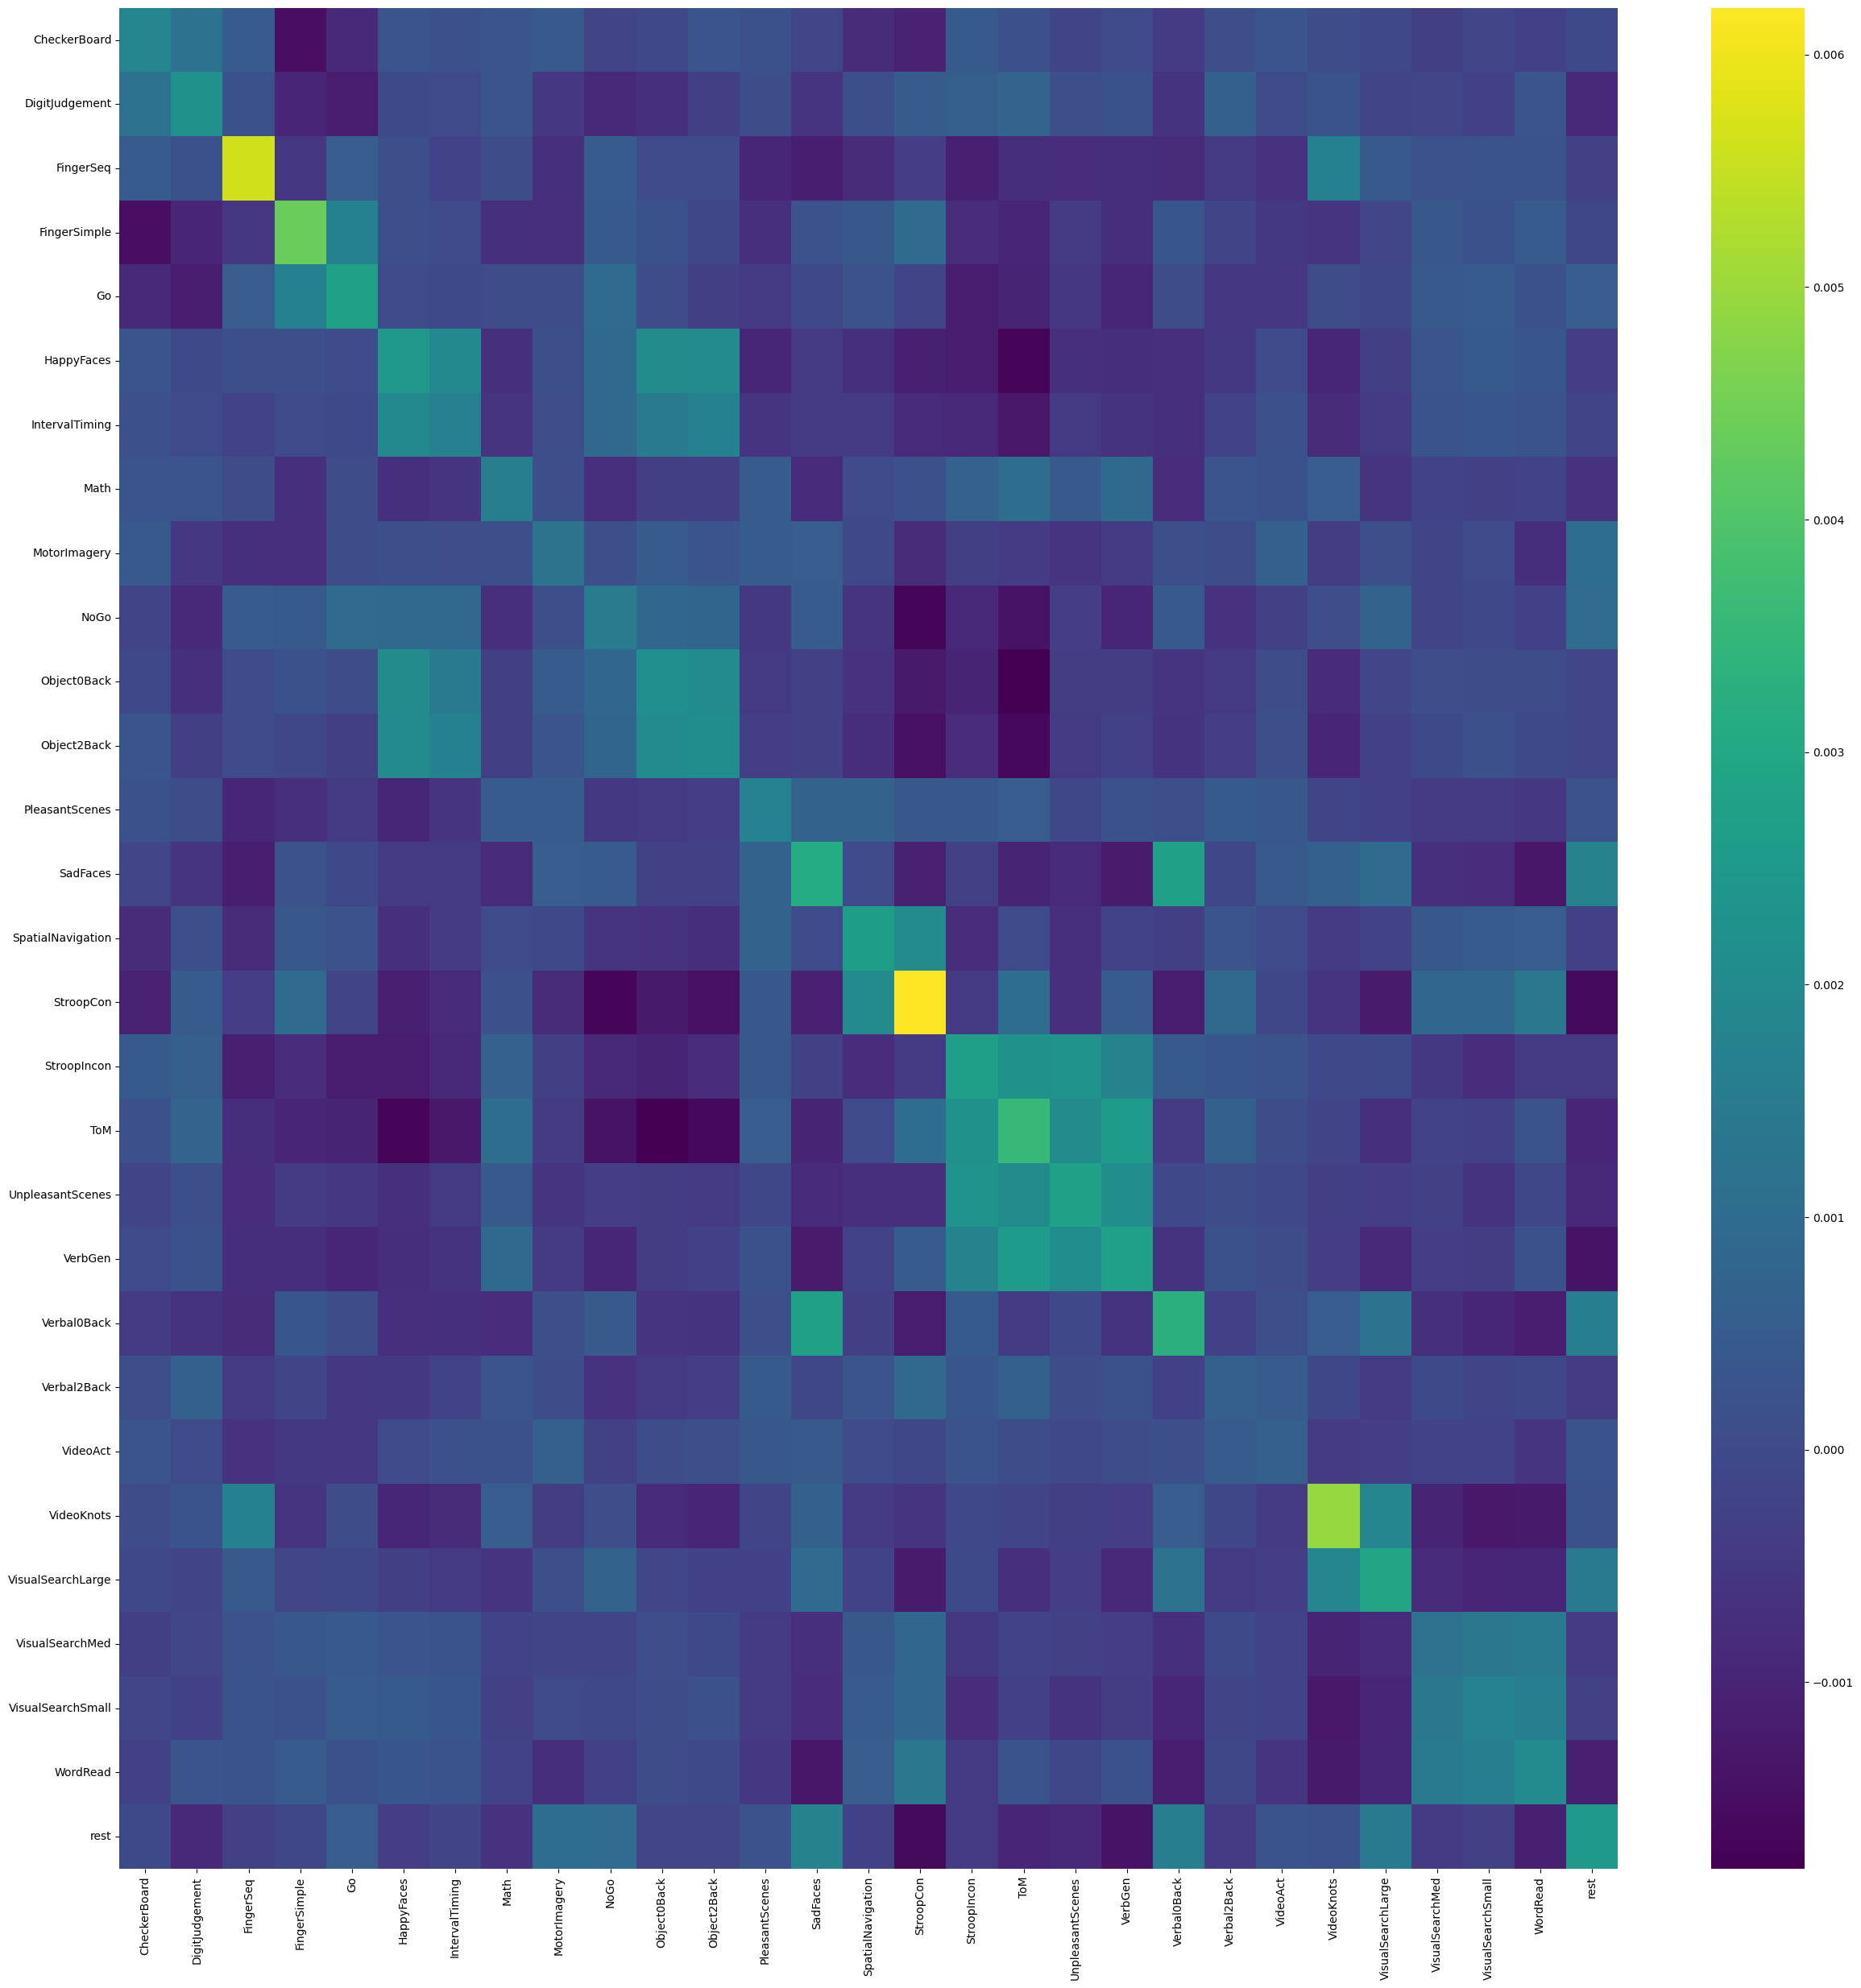

In [16]:
plt.figure(figsize=(30, 30))
sns.heatmap(G_individuals_averaged,xticklabels=cond_names, yticklabels=cond_names, cmap='viridis')

# Build combinations

In [25]:
D = build_combinations(G_individuals_averaged, strategy='random',n_iter=100,n_tasks=8)

In [26]:
np.unique(D.n_unique)
A = D[D['offset'] == 0.001].copy()

<Axes: xlabel='min_est', ylabel='max_var'>

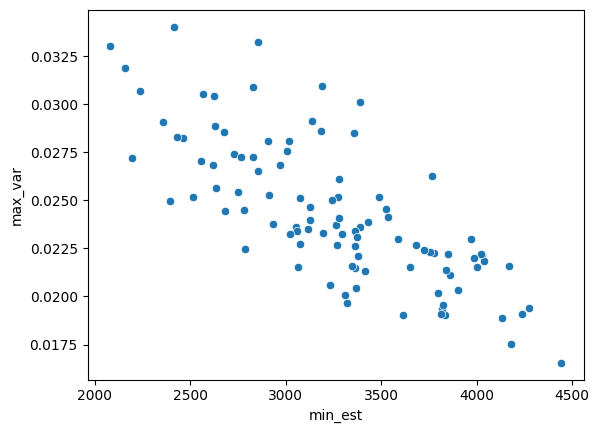

In [27]:
sns.scatterplot(x='min_est',y='max_var',data=A)

# Perform DCBC on combinations

In [28]:
#load model
with open('E:/data/model.pkl', 'rb') as f:
    model = pickle.load(f)

sym_type = 'unsym'
ar_model = model.arrange
ar_model.logpi = pt.tensor(ar_model.logpi, dtype=pt.get_default_dtype())

P = data_mdtb_s1.shape[2]
K = ar_model.K

#load dist matrix
with open('E:/data/dist.pkl', 'rb') as f:
    dist = pickle.load(f)

dist = dist.to(DEVICE)


# load evaluation data_mdtb_s2
with open('E:/data/data_mdtb_s2_SUIT3.pkl', 'rb') as f:
    data_mdtb_s2 = pickle.load(f)


#check nans
np.isnan(data_mdtb_s2).sum()




c:\Users\basse\AppData\Local\Programs\Python\Python38\lib\site-packages\torch\utils\_device.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


0

In [29]:
def perform_dcbc_combination(dt,c_v,p_v,data_eval):
    
    x_matrix = ut.indicator(c_v)
    em_model = em.MixVMF(K=K, P=dt.shape[2], X=x_matrix, part_vec=p_v,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([dt])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)    

    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation
    
    if isinstance(data_eval, np.ndarray):
        data_eval = pt.tensor(data_eval, dtype=pt.get_default_dtype())
    if isinstance(U_data, np.ndarray):
        U_data = pt.tensor(U_data, dtype=pt.get_default_dtype())
    
    Pindiv = pt.argmax(U_data, dim=1) + 1
    dcbc_indiv = calc_test_dcbc(Pindiv, data_eval, dist,progress_updates= False)
    return dcbc_indiv.mean()


In [30]:
# def perform_cos_combination(data_train,cond_vec,part_vec,data_eval):

#     x_matrix = ut.indicator(cond_vec)    
#     em_model = em.MixVMF(K=K, P=data_train.shape[2], X=x_matrix, part_vec=part_vec,
#                          subject_specific_kappa=False, parcel_specific_kappa=False, 
#                          subjects_equal_weight=True)
    
#     M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
#     M_1.initialize([data_train])

#     M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
#                                      fit_arrangement=False,
#                                      fit_emission= True,
#                                      first_evidence=False)
    

#     # Get the data-only parcellation
#     emloglik = M_1.emissions[0].Estep()
#     U_data = pt.softmax(emloglik, dim=1) # get data only parcellation

#     parcellation = [U_data]
    
#     if isinstance(data_eval, np.ndarray):
#         data_eval = pt.tensor(data_eval, dtype=pt.get_default_dtype())
#     if isinstance(parcellation, np.ndarray):
#         parcellation = pt.tensor(parcellation, dtype=pt.get_default_dtype())

#     eval_num_runs = 16
#     eval_num_conds = 32

#     #create cond_vec and part_vec for evaluation data
#     cond_v_eval = np.tile(np.arange(1, eval_num_conds + 1), eval_num_runs)
#     part_v_eval = np.repeat(np.arange(1, eval_num_runs + 1), eval_num_conds)
#     #make into pt tensors
#     part_v_eval = pt.tensor(part_v_eval, dtype=pt.long)

#     x_matrix  = ut.indicator(cond_v_eval)

#     em_model = em.MixVMF(K=K, P=data_eval.shape[2], X=x_matrix, part_vec=part_v_eval,
#                             subject_specific_kappa=False, parcel_specific_kappa=False, 
#                             subjects_equal_weight=True)
    
#     M_eval = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
#     M_eval.initialize([data_eval])
    
#     cosserror_individuals = calc_test_error(M_eval, data_eval, parcellation)
#     return cosserror_individuals.mean()

In [31]:
counter = 0
def evaluate_combination_dcbc(combination):
    global counter
    counter += 1
    print(f"Combination {counter}")

    combination = [2,5,3,7,9,12,15,13]
    data_train, cond_v_train, part_v_train = combination_vectors(data_mdtb_s1, info, combination, n_repeats=2)
    dcbc_value = perform_dcbc_combination(data_train, cond_v_train, part_v_train, data_mdtb_s2)
    dcbc_value = dcbc_value.item()
    
    return dcbc_value

# def evaluate_combination_cos(combination):
#     global counter
#     counter += 1
#     print(f"Combination {counter}")
#     data_train, cond_v_train, part_v_train = combination_vectors(data_mdtb_s1, info, combination, n_repeats=3)
#     cos_value = perform_cos_combination(data_train, cond_v_train, part_v_train, data_mdtb_s2)
#     cos_value = cos_value.item()
    
#     return cos_value

In [ ]:
unique_combinations_df = D[D['offset'] == D['offset'].min()].copy()
unique_combinations_df['dcbc'] = unique_combinations_df['combination'].apply(evaluate_combination_dcbc)


Combination 1
Likelihood decreased - terminating on iteration 1
Combination 2
Likelihood decreased - terminating on iteration 1
Combination 3
Likelihood decreased - terminating on iteration 1
Combination 4
Likelihood decreased - terminating on iteration 1
Combination 5
Likelihood decreased - terminating on iteration 1
Combination 6
Likelihood decreased - terminating on iteration 1
Combination 7
Likelihood decreased - terminating on iteration 1
Combination 8
Likelihood decreased - terminating on iteration 1
Combination 9
Likelihood decreased - terminating on iteration 1
Combination 10
Likelihood decreased - terminating on iteration 1
Combination 11
Likelihood decreased - terminating on iteration 1
Combination 12
Likelihood decreased - terminating on iteration 1
Combination 13
Likelihood decreased - terminating on iteration 1
Combination 14
Likelihood decreased - terminating on iteration 1
Combination 15
Likelihood decreased - terminating on iteration 1
Combination 16
Likelihood decrease

In [115]:
# unique_combinations_df = D[D['offset'] == D['offset'].min()].copy()
# unique_combinations_df['cos'] = unique_combinations_df['combination'].apply(evaluate_combination_cos)

In [38]:
D['combination'] = D['combination'].apply(tuple)
unique_combinations_df['combination'] = unique_combinations_df['combination'].apply(tuple)

# Now perform the merge operation using the tuple values
D = D.merge(
    unique_combinations_df[['combination', 'dcbc']], 
    on='combination', 
    how='left'
)

In [139]:
# # save D as tsv
# D.to_csv('dcbc_combinations_SUIT3_full_cerebellum.tsv', sep='\t', index=False)

In [140]:
# D = pd.read_csv('dcbc_combinations_SUIT3_full_cerebellum.tsv', sep='\t')

# Analyze the results

In [39]:
D

,offset,max_var,min_est,log_det,off_diag,composite_90var,composite_75var,composite_50var,composite_25var,composite_10var,composite_0.01var,condition_number,effective_rank,combination,has_repeats,n_unique,dcbc
0,0.000001,0.021663,2.001470e+06,-55.492678,0.000060,0.694773,0.578967,0.385958,0.192949,0.077144,0.007661,108607.447042,9.110395,"(28, 10, 28, 14, 18, 4, 23, 23)",1,6,0.048589
1,0.001000,0.028656,3.099040e+03,-40.413351,0.000060,0.694773,0.578967,0.385958,0.192949,0.077144,0.007661,108607.447042,9.110395,"(28, 10, 28, 14, 18, 4, 23, 23)",1,6,0.048589
2,0.100000,0.721656,6.794797e+01,-15.907335,0.000060,0.694773,0.578967,0.385958,0.192949,0.077144,0.007661,108607.447042,9.110395,"(28, 10, 28, 14, 18, 4, 23, 23)",1,6,0.048589
3,0.000001,0.016151,2.003116e+06,-57.773235,0.000028,0.679892,0.566572,0.377705,0.188839,0.075519,0.007527,106485.582349,8.725082,"(9, 17, 23, 0, 22, 13, 9, 9)",1,6,0.042855
4,0.001000,0.023144,3.580494e+03,-41.831051,0.000028,0.679892,0.566572,0.377705,0.188839,0.075519,0.007527,106485.582349,8.725082,"(9, 17, 23, 0, 22, 13, 9, 9)",1,6,0.042855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.001000,0.026736,2.534559e+03,-40.050709,0.000023,0.689592,0.574656,0.383096,0.191537,0.076601,0.007639,387.810947,9.061420,"(2, 4, 5, 22, 7, 18, 12, 13)",0,8,0.046039
296,0.100000,0.719736,6.810631e+01,-15.924796,0.000023,0.689592,0.574656,0.383096,0.191537,0.076601,0.007639,387.810947,9.061420,"(2, 4, 5, 22, 7, 18, 12, 13)",0,8,0.046039
297,0.000001,0.018120,1.005015e+06,-51.365574,0.000043,0.685208,0.570999,0.380652,0.190304,0.076096,0.007571,108381.444628,8.852726,"(0, 21, 18, 28, 7, 28, 15, 25)",1,7,0.046164
298,0.001000,0.025113,3.222527e+03,-41.297613,0.000043,0.685208,0.570999,0.380652,0.190304,0.076096,0.007571,108381.444628,8.852726,"(0, 21, 18, 28, 7, 28, 15, 25)",1,7,0.046164


In [40]:
# subset only the 0.001 offset
A = D[D['offset'] == 0.001].copy()

<Axes: xlabel='has_repeats', ylabel='log_det'>

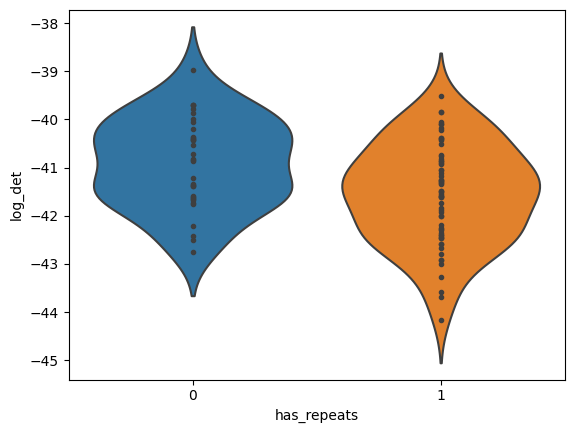

In [41]:
sns.violinplot(data=A, x='has_repeats', y='log_det', inner='point')

In [42]:
# show many combinations are repeated
n_repeated = len(A[A['has_repeats'] == True])
n_unique = len(A[A['has_repeats'] == False])

n_repeated, n_unique


(65, 35)

<Axes: xlabel='dcbc', ylabel='Count'>

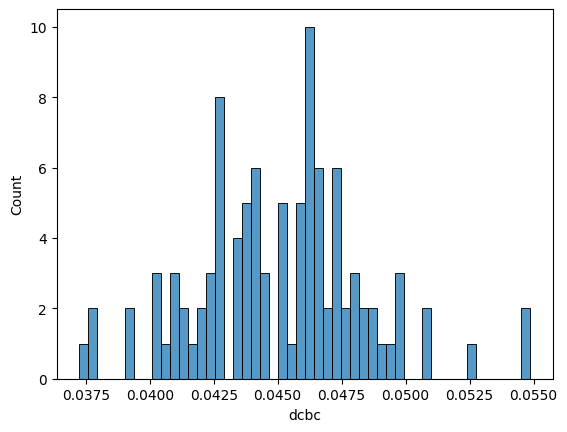

In [43]:
# plot the distribution of the DCBC values
sns.histplot(A['dcbc'], bins=50)

<Axes: xlabel='min_est', ylabel='max_var'>

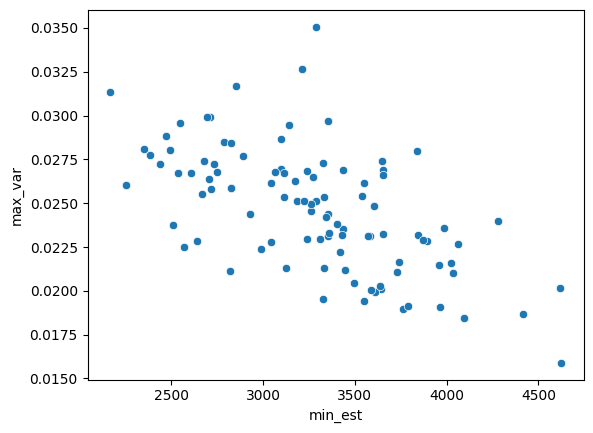

In [44]:
sns.scatterplot(x='min_est', y='max_var', data=A)

In [45]:
# get the two variables for Dcbc and log_det
log_det_list = A['log_det'].values
dcbc_list = A['dcbc'].values

from scipy.stats import pearsonr
r_value, p_value = pearsonr(log_det_list, dcbc_list)

print(f"Correlation between log_det and DCBC: {r_value}, p-value: {p_value}")

Correlation between log_det and DCBC: 0.3148005882888362, p-value: 0.0014230191211728766


In [46]:
# get the two variables for DCBC and min_est
min_est_list = A['min_est'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(min_est_list, dcbc_list)

print(f"Correlation between min_est and DCBC: {r_value}, p-value: {p_value}")


Correlation between min_est and DCBC: -0.17023904108400972, p-value: 0.09038470979915067


In [47]:
# get the two variables for DCBC and max_var
max_var_list = A['max_var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: 0.44796925673162424, p-value: 2.9614856642369134e-06


In [149]:
# get the two variables for DCBC and max_var
max_var_list = A['effective_rank'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: -0.15601774509273808, p-value: 0.12112455550731889


In [150]:
# get the two variables for DCBC and max_var
max_var_list = A['max_var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: -0.18116526874599587, p-value: 0.07125744702860767


In [151]:
# get the two variables for DCBC and max_var
max_var_list = A['composite_90var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: -0.18115232479108362, p-value: 0.07127800096886698


In [152]:
# get the two variables for DCBC and max_var
max_var_list = A['composite_75var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: -0.18112642572447274, p-value: 0.0713191409294213


In [153]:
# get the two variables for DCBC and max_var
max_var_list = A['composite_50var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: -0.18104863919245084, p-value: 0.07144281792656867


In [154]:
# get the two variables for DCBC and max_var
max_var_list = A['composite_10var'].values
dcbc_list = A['dcbc'].values

r_value, p_value = pearsonr(max_var_list, dcbc_list)

print(f"Correlation between max_var and DCBC: {r_value}, p-value: {p_value}")

Correlation between max_var and DCBC: -0.18010466761685132, p-value: 0.07295752538948634
